In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm.autonotebook import tqdm
import pandas as pd

/tmp/ipykernel_1182/3542236899.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
%matplotlib inline
#from IPython.display import set_matplotlib_formats
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats('png', 'pdf')

In [3]:
import torch

In [4]:
torch_scalar = torch.tensor(3.14)
torch_vector = torch.tensor([1, 2, 3, 4])
torch_matrix = torch.tensor([[1, 2,],
                             [3, 4,],
                             [5, 6,], 
                             [7, 8,]])
#You don't have to format it like I did, thats just for clarity
torch_tensor3d = torch.tensor([
                            [
                            [ 1,  2,  3], 
                            [ 4,  5,  6],
                            ],
                            [
                            [ 7,  8,  9], 
                            [10, 11, 12],
                            ],
                            [
                            [13, 14, 15], 
                            [16, 17, 18],
                            ],
                            [
                            [19, 20, 21], 
                            [22, 23, 24],
                            ]
                              ])

In [5]:
print(torch_scalar.shape)
print(torch_vector.shape)
print(torch_matrix.shape)
print(torch_tensor3d.shape)

torch.Size([])
torch.Size([4])
torch.Size([4, 2])
torch.Size([4, 2, 3])


In [6]:
x_np = np.random.random((4,4))
print(x_np)

[[0.66634532 0.23120982 0.04602676 0.25410683]
 [0.26291556 0.80682435 0.8365258  0.5784792 ]
 [0.19148008 0.28535249 0.99862375 0.21913728]
 [0.1053286  0.88839362 0.40782654 0.53734437]]


In [7]:
x_pt = torch.tensor(x_np)
print(x_pt)

tensor([[0.6663, 0.2312, 0.0460, 0.2541],
        [0.2629, 0.8068, 0.8365, 0.5785],
        [0.1915, 0.2854, 0.9986, 0.2191],
        [0.1053, 0.8884, 0.4078, 0.5373]], dtype=torch.float64)


In [8]:
print(x_np.dtype, x_pt.dtype)

float64 torch.float64


In [9]:
#Lets force them to be 32-bit floats
x_np = np.asarray(x_np, dtype=np.float32)
x_pt = torch.tensor(x_np, dtype=torch.float32)
print(x_np.dtype, x_pt.dtype)

float32 torch.float32


In [10]:
b_np = (x_np > 0.5)
print(b_np)
print(b_np.dtype)

[[ True False False False]
 [False  True  True  True]
 [False False  True False]
 [False  True False  True]]
bool


In [11]:
b_pt = (x_pt > 0.5)
print(b_pt)
print(b_pt.dtype)

tensor([[ True, False, False, False],
        [False,  True,  True,  True],
        [False, False,  True, False],
        [False,  True, False,  True]])
torch.bool


In [12]:
np.sum(x_np)

np.float32(7.315921)

In [13]:
torch.sum(x_pt)

tensor(7.3159)

In [14]:
np.transpose(x_np)

array([[0.6663453 , 0.26291555, 0.19148009, 0.1053286 ],
       [0.23120981, 0.8068243 , 0.2853525 , 0.88839364],
       [0.04602676, 0.8365258 , 0.9986237 , 0.40782654],
       [0.25410682, 0.5784792 , 0.21913728, 0.5373444 ]], dtype=float32)

In [15]:
torch.transpose(x_pt, 0, 1)

tensor([[0.6663, 0.2629, 0.1915, 0.1053],
        [0.2312, 0.8068, 0.2854, 0.8884],
        [0.0460, 0.8365, 0.9986, 0.4078],
        [0.2541, 0.5785, 0.2191, 0.5373]])

In [16]:
print(torch.transpose(torch_tensor3d, 0, 2).shape)

torch.Size([3, 2, 4])


In [11]:
import timeit
x = torch.rand(2**11, 2**11)
time_cpu = timeit.timeit("x@x", globals=globals(), number=100)

In [12]:
print("Is CUDA available? :", torch.cuda.is_available())
device = torch.device("cuda")

Is CUDA available? : True


In [21]:
x = x.to(device)
time_gpu = timeit.timeit("x@x", globals=globals(), number=100)

In [22]:
print(f'CPU Time:{time_cpu}, GPU Time:{time_gpu}, Speedup:{time_cpu/time_gpu}x')

CPU Time:8.85008064005524, GPU Time:0.008929666597396135, Speedup:991.0874659795134x


In [23]:
def moveTo(obj, device):
    """
    obj: the python object to move to a device, or to move its contents to a device
    device: the compute device to move objects to
    """
    if isinstance(obj, list):
        return [moveTo(x, device) for x in obj]
    elif isinstance(obj, tuple):
        return tuple(moveTo(list(obj), device))
    elif isinstance(obj, set):
        return set(moveTo(list(obj), device))
    elif isinstance(obj, dict):
        to_ret = dict()
        for key, value in obj.items():
            to_ret[moveTo(key, device)] = moveTo(value, device)
        return to_ret
    elif hasattr(obj, "to"):
        return obj.to(device)
    else:
        return obj
    
some_tensors = [torch.tensor(1), torch.tensor(2)]
print(some_tensors)
print(moveTo(some_tensors, device))

[tensor(1), tensor(2)]
[tensor(1, device='cuda:0'), tensor(2, device='cuda:0')]


<Axes: >

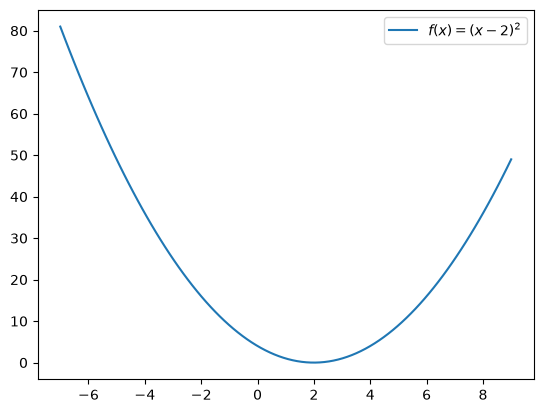

In [24]:
def f(x):
    return torch.pow((x-2.0), 2)

x_axis_vals = np.linspace(-7,9,100) 
y_axis_vals = f(torch.tensor(x_axis_vals)).numpy()

sns.lineplot(x=x_axis_vals, y=y_axis_vals, label='$f(x)=(x-2)^2$')

<Axes: >

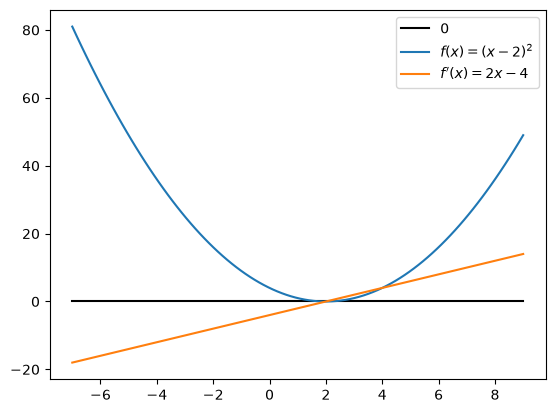

In [25]:
def fP(x): #Defining the derivative of f(x) manually
    return 2*x-4

y_axis_vals_p = fP(torch.tensor(x_axis_vals)).numpy()

#First, lets draw a black line at 0, so that we can easily tell if something is positive or negative
sns.lineplot(x=x_axis_vals, y=[0.0]*len(x_axis_vals), label="0", color='black')
sns.lineplot(x=x_axis_vals, y=y_axis_vals, label='$f(x) = (x-2)^2$')
sns.lineplot(x=x_axis_vals, y=y_axis_vals_p, label="$f'(x)=2 x - 4$")

In [26]:
x = torch.tensor([-3.5], requires_grad=True)
print(x.grad)

None


In [27]:
value = f(x)
print(value)

tensor([30.2500], grad_fn=<PowBackward0>)


In [28]:
value.backward()
print(x.grad)

tensor([-11.])


In [34]:
x = torch.tensor([-3.5], requires_grad=True)

x_cur = x.clone()
x_prev = x_cur*100 #Make the initial "previous" solution larger
epsilon = 1e-5
eta = 0.1

step = 0
print(f'Step {step} : {x_cur}')
while torch.linalg.norm(x_cur-x_prev) > epsilon:
    x_prev = x_cur.clone() #We need to make a clone here so that x_prev and x_cur don't point to the same object
    
    #Compute our function, gradient, and update
    value = f(x)
    value.backward()
    x.data -= eta * x.grad
    x.grad.zero_() #We need to zero out the old gradient, as py-torch will not do that for us
    
    #What are we currently now?
    x_cur = x.data
    print(f'Step {step+1} : {x_cur}')
    step = step + 1
    
print(x_cur)

Step 0 : tensor([-3.5000], grad_fn=<CloneBackward0>)
Step 1 : tensor([-2.4000])
Step 2 : tensor([-1.5200])
Step 3 : tensor([-0.8160])
Step 4 : tensor([-0.2528])
Step 5 : tensor([0.1978])
Step 6 : tensor([0.5582])
Step 7 : tensor([0.8466])
Step 8 : tensor([1.0773])
Step 9 : tensor([1.2618])
Step 10 : tensor([1.4094])
Step 11 : tensor([1.5276])
Step 12 : tensor([1.6220])
Step 13 : tensor([1.6976])
Step 14 : tensor([1.7581])
Step 15 : tensor([1.8065])
Step 16 : tensor([1.8452])
Step 17 : tensor([1.8762])
Step 18 : tensor([1.9009])
Step 19 : tensor([1.9207])
Step 20 : tensor([1.9366])
Step 21 : tensor([1.9493])
Step 22 : tensor([1.9594])
Step 23 : tensor([1.9675])
Step 24 : tensor([1.9740])
Step 25 : tensor([1.9792])
Step 26 : tensor([1.9834])
Step 27 : tensor([1.9867])
Step 28 : tensor([1.9894])
Step 29 : tensor([1.9915])
Step 30 : tensor([1.9932])
Step 31 : tensor([1.9946])
Step 32 : tensor([1.9956])
Step 33 : tensor([1.9965])
Step 34 : tensor([1.9972])
Step 35 : tensor([1.9978])
Step 36

In [36]:
x_param = torch.nn.Parameter(torch.tensor([-3.5]), requires_grad=True)

In [38]:
optimizer = torch.optim.SGD([x_param], lr=eta)

In [39]:
for epoch in range(60):
    optimizer.zero_grad() #x.grad.zero_()
    loss_incurred  = f(x_param)
    loss_incurred.backward()
    optimizer.step() #x.data -= eta * x.grad
    print(f'Epoch {epoch}: x:{x_param}')
print(x_param.data)

Epoch 0: x:Parameter containing:
tensor([-2.4000], requires_grad=True)
Epoch 1: x:Parameter containing:
tensor([-1.5200], requires_grad=True)
Epoch 2: x:Parameter containing:
tensor([-0.8160], requires_grad=True)
Epoch 3: x:Parameter containing:
tensor([-0.2528], requires_grad=True)
Epoch 4: x:Parameter containing:
tensor([0.1978], requires_grad=True)
Epoch 5: x:Parameter containing:
tensor([0.5582], requires_grad=True)
Epoch 6: x:Parameter containing:
tensor([0.8466], requires_grad=True)
Epoch 7: x:Parameter containing:
tensor([1.0773], requires_grad=True)
Epoch 8: x:Parameter containing:
tensor([1.2618], requires_grad=True)
Epoch 9: x:Parameter containing:
tensor([1.4094], requires_grad=True)
Epoch 10: x:Parameter containing:
tensor([1.5276], requires_grad=True)
Epoch 11: x:Parameter containing:
tensor([1.6220], requires_grad=True)
Epoch 12: x:Parameter containing:
tensor([1.6976], requires_grad=True)
Epoch 13: x:Parameter containing:
tensor([1.7581], requires_grad=True)
Epoch 14: x:

In [56]:
from torch.utils.data import Dataset
from sklearn.datasets import fetch_openml

# Load data from https://www.openml.org/d/554
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
print(X.shape)

(70000, 784)


In [57]:
class SimpleDataset(Dataset):
        
    def __init__(self, X, y):
        super(SimpleDataset, self).__init__()
        self.X = X
        self.y = y
    
    def __getitem__(self, index):
        #This "work" could have gone in the constructor, but you should get into 
        inputs = torch.tensor(self.X[index,:], dtype=torch.float32)
        targets = torch.tensor(int(self.y[index]), dtype=torch.int64)
        return inputs, targets 

    def __len__(self):
        return self.X.shape[0]
#Now we can make a PyTorch dataset 
dataset = SimpleDataset(X, y)

In [58]:
dataset[0]

(tensor([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,  

In [59]:
print("Length: ", len(dataset))
example, label = dataset[0]
print("Features: ", example.shape) #Will return 784
print("Label of index 0: ", label)

Length:  70000
Features:  torch.Size([784])
Label of index 0:  tensor(5)


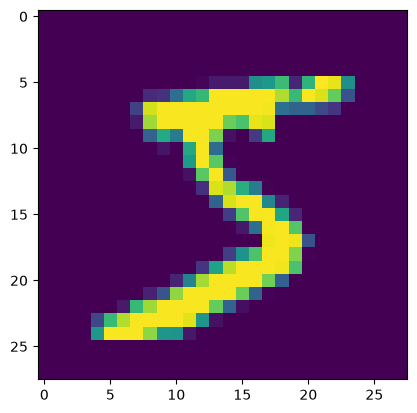

In [60]:
plt.imshow(example.reshape((28,28)))

In [61]:
train_size = int(len(dataset)*0.8)
test_size = len(dataset)-train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, (train_size, test_size))
print("{} examples for training and {} for testing".format(len(train_dataset), len(test_dataset)))

56000 examples for training and 14000 for testing
